# Evaluating Machine Learning Models

# Linear Regression 

California housing dataset!

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
from sklearn import tree
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
california_housing_features = pd.DataFrame(data=housing.data, columns=housing.feature_names)
california_housing_features.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
california_housing_target = pd.DataFrame(data=housing.target,columns=['price'])

In [4]:
california_housing_split = train_test_split(
    california_housing_features,
    california_housing_target,
    test_size=0.25,
    random_state=17
)

california_housing_features_train = california_housing_split[0]
california_housing_features_test = california_housing_split[1]
california_housing_target_train = california_housing_split[2]
california_housing_target_test = california_housing_split[3]

In [5]:
linear_regression_model = LinearRegression(fit_intercept=True)
linear_regression_model.fit(
    california_housing_features_train,
    california_housing_target_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
dtree_reg_model = DecisionTreeRegressor(max_depth=10)
dtree_reg_model.fit(california_housing_features_train,california_housing_target_train.values.ravel())


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [7]:
linear_reg_predictions = linear_regression_model.predict(california_housing_features_test)
dtree_reg_predictions = dtree_reg_model.predict(california_housing_features_test)

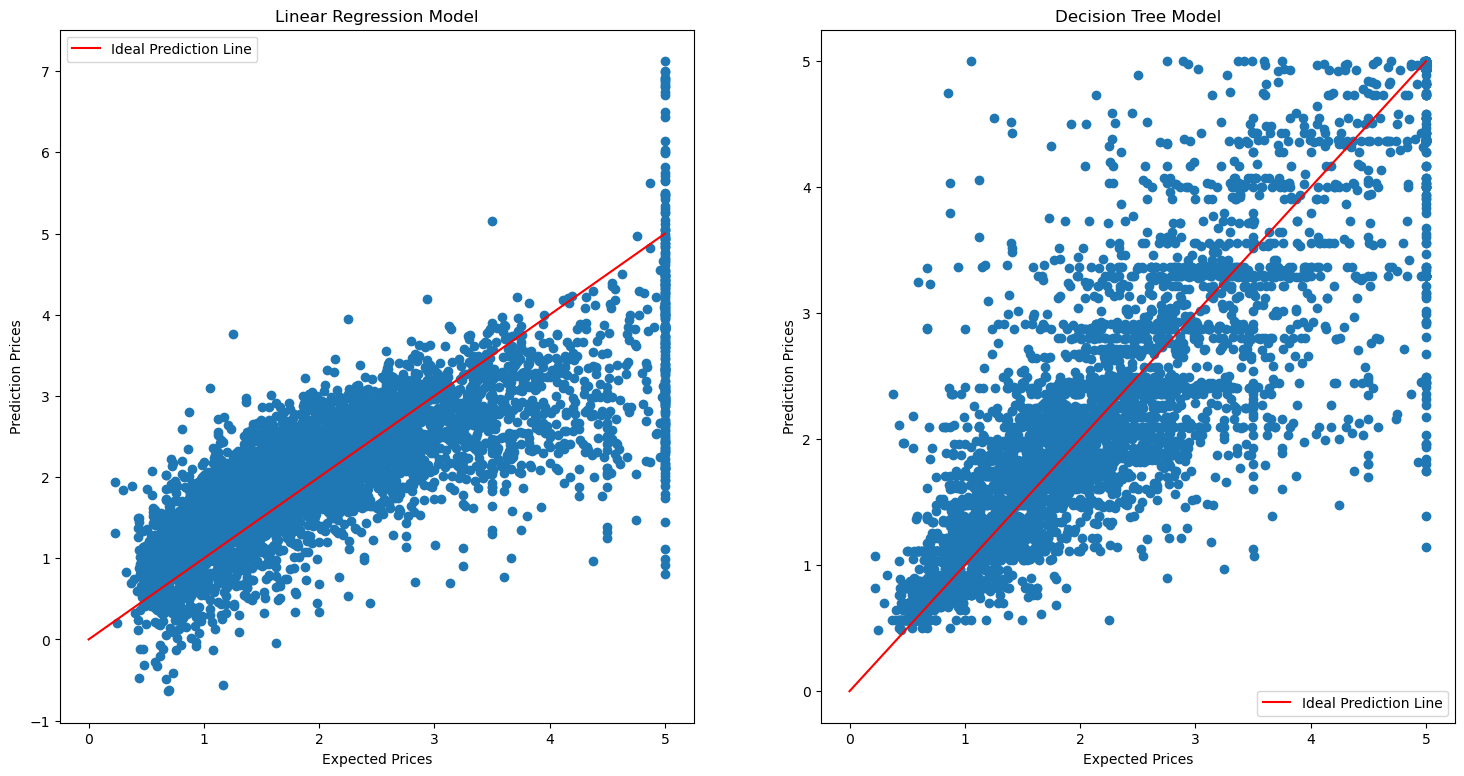

In [8]:
fig,axes = plt.subplots(1,2,figsize=(18,9))
axes[0].scatter(california_housing_target_test, linear_reg_predictions)
axes[0].set_xlabel('Expected Prices')
axes[0].set_ylabel('Prediction Prices')
axes[0].set_title('Linear Regression Model')

axes[1].scatter(california_housing_target_test, dtree_reg_predictions)
axes[1].set_xlabel('Expected Prices')
axes[1].set_ylabel('Prediction Prices')
axes[1].set_title('Decision Tree Model')

IdealPrices = np.linspace(0.0, california_housing_target_test.values.max(), 50)
IdealPredictions = IdealPrices
axes[0].plot(IdealPrices, IdealPredictions, color='#ff0000',label='Ideal Prediction Line')
axes[1].plot(IdealPrices,IdealPredictions,color='#ff0000', label='Ideal Prediction Line')

axes[0].legend()
axes[1].legend()

# RMSE Metric

Root Mean Square Error - the eorr in predicted value value minus the actual (squared). Can be positive or negative, squaring ensures that the direction is irrelevant.

Having a lower score is good here.

In [9]:
mse_linear_reg_model = mean_squared_error(california_housing_target_test, linear_reg_predictions)
mse_dtree_reg_model = mean_squared_error(california_housing_target_test, dtree_reg_predictions)

rmse_linear_reg_model = sqrt(mse_linear_reg_model)
rmse_dtree_reg_model = sqrt(mse_dtree_reg_model)


In [10]:
print(rmse_linear_reg_model,rmse_dtree_reg_model)

0.7249575191045401 0.6262489981667653


# R^2 Metric

R^2 metric measures the distrance of the predicted points from the regression line.

Having a higher score is good here.

In [11]:
r2_linear_reg_model =  r2_score(california_housing_target_test, linear_reg_predictions)
r2_dtree_reg_model = r2_score(california_housing_target_test, dtree_reg_predictions)

In [12]:
print(r2_linear_reg_model,r2_dtree_reg_model)


0.6006728254324019 0.7020126443206365


# Binary Classification Models

In [13]:
diabetes_file = 'C:/Users/deanc/Documents/Datasets/Diabetes/diabetes.csv'
df_diabetes = pd.read_csv(diabetes_file)
df_diabetes_target = df_diabetes.loc[:,['Outcome']]
df_diabetes_features = df_diabetes.drop(['Outcome'],axis=1)
#normalize the attributes
diabetes_scaler = MinMaxScaler()
diabetes_scaler.fit(df_diabetes_features)
nd_diabetes_features = diabetes_scaler.transform(df_diabetes_features)
df_diabetes_normalized = pd.DataFrame(data=nd_diabetes_features, columns=df_diabetes_features.columns)

In [14]:
#Create test and training sets
df_diabetes_split = train_test_split(
    df_diabetes_normalized,
    df_diabetes_target,
    test_size =0.25,
    random_state=17
)
df_diabetes_features_train = df_diabetes_split[0]
df_diabetes_features_test = df_diabetes_split[1]
df_diabetes_target_train = df_diabetes_split[2]
df_diabetes_target_test = df_diabetes_split[3]

In [15]:
svc_model = SVC(kernel='rbf', C=1, gamma='auto')
svc_model.fit(df_diabetes_features_train,df_diabetes_target_train.values.ravel())


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
logit_model = LogisticRegression(l1_ratio=0, fit_intercept=True,solver='liblinear')
logit_model.fit(df_diabetes_features_train, df_diabetes_target_train.values.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [17]:
#Train a decision tree now
dtree_model = DecisionTreeClassifier(max_depth=4)
dtree_model.fit(df_diabetes_features_train,df_diabetes_target_train.values.ravel())

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [18]:
svc_predictions = svc_model.predict(df_diabetes_features_test)
logit_predictions = logit_model.predict(df_diabetes_features_test)
dtree_predictions = dtree_model.predict(df_diabetes_features_test)

In [19]:
svc_correct = svc_predictions == df_diabetes_target_test.values.ravel()
svc_correct_percent = np.count_nonzero(svc_correct)/svc_predictions.size * 100

In [20]:
logit_correct = logit_predictions == df_diabetes_target_test.values.ravel()
logit_correct_percent = np.count_nonzero(logit_correct)/logit_predictions.size * 100

In [21]:
dtree_correct = dtree_predictions == df_diabetes_target_test.values.ravel()
dtree_correct_percent = np.count_nonzero(dtree_correct)/dtree_predictions.size * 100

In [22]:
print(svc_correct_percent,logit_correct_percent,dtree_correct_percent)

73.95833333333334 76.5625 75.52083333333334


# Class-Wise Confusion AKA Confusion Matrix

Additional metrics to determine model performance include looking at:

True Positive Count: The number of times the model predicited positive outcome and the outcome was predicited correctly.

False Positive Count: The number of times the model predicited positive and the outcome was predicted incorrectly.

True Negative Count: The number of times the model predicited negative and the outcome was predicted correctly. 

False Negative Count: The number of times the model predicted a negative outcome and was predicted incorrectly. 

In [23]:
cm_svc = confusion_matrix(df_diabetes_target_test.values.ravel(),svc_predictions)
cm_logit = confusion_matrix(df_diabetes_target_test.values.ravel(),logit_predictions)
cm_dtree = confusion_matrix(df_diabetes_target_test.values.ravel(),dtree_predictions)

In [24]:
#Exact true negative, false positive, false negative, true positive (TN,FP,FN,TP)
#The sklearn confusion_matrix() function returns in the following matrix

tn_svc, fp_svc, fn_svc, tp_svc = cm_svc.ravel()
tn_logit, fp_logit, fn_logit, tp_logit = cm_logit.ravel()
tn_dtree, fp_dtree, fn_dtree, tp_dtree = cm_dtree.ravel()

In [25]:
print(tn_svc, fp_svc, fn_svc, tp_svc)

113 8 42 29


In [26]:
print(tn_logit, fp_logit, fn_logit, tp_logit)

113 8 37 34


In [27]:
print(tn_dtree, fp_dtree, fn_dtree, tp_dtree)

103 18 29 42


# In addition to using Confusion matrix, we can use Accuracy to evaluate models

Accuracy = (TP + TN)/Total # of Predictions 

Precision = TP/(TP+FP) (TP/Total number of positive prediction)

Recall = TP/(TP+FN) (TP/Total # of positive samples in the dataset) Is there a high cost associated with false negatives


In [28]:
accuracy_svc = (tp_svc + tn_svc)/ (tn_svc+fp_svc+fn_svc+tp_svc)
precision_svc = tp_svc/(tp_svc+fp_svc)
recall_svc = tp_svc/(tp_svc+ fn_svc)

In [29]:
accuracy_logit = (tp_logit + tn_logit)/ (tn_logit+fp_logit+fn_logit+tp_logit)
precision_logit = tp_logit/(tp_logit+fp_logit)
recall_logit = tp_logit/(tp_logit+ fn_logit)

In [30]:
accuracy_dtree = (tp_dtree + tn_dtree)/ (tn_dtree+fp_dtree+fn_dtree+tp_dtree)
precision_dtree = tp_svc/(tp_dtree+fp_dtree)
recall_dtree = tp_dtree/(tp_dtree+fn_dtree)

In [31]:
print(accuracy_svc,precision_svc,recall_svc)

0.7395833333333334 0.7837837837837838 0.4084507042253521


In [32]:
print(accuracy_logit,precision_logit,recall_logit)

0.765625 0.8095238095238095 0.4788732394366197


In [33]:
print(accuracy_dtree,precision_dtree,recall_dtree)

0.7552083333333334 0.48333333333333334 0.5915492957746479


In [34]:
#plot ROC curves for the three classifiers

#compute prediction probabilities
svc_model = SVC(probability=True)
svc_model.fit(df_diabetes_features_train,df_diabetes_target_train.values.ravel())
svc_probabilities = svc_model.predict_proba(df_diabetes_features_test)


logit_probabilities = logit_model.predict_proba(df_diabetes_features_test)
dtree_probabilities = dtree_model.predict_proba(df_diabetes_features_test)



In [35]:
#Calculate the FPR and TPR for all thresholds of the SVC model
svc_fpr,svc_tpr,svc_thresholds = metrics.roc_curve(
    df_diabetes_target_test.values.ravel(),
    svc_probabilities[:,1],
    pos_label=1,
    drop_intermediate=False
)

In [36]:
#Calculate the FPR and TPR for all thresholds of the logistic regression model
logit_fpr,logit_tpr,logit_thresholds = metrics.roc_curve(
    df_diabetes_target_test.values.ravel(),
    logit_probabilities[:,1],
    pos_label=1,
    drop_intermediate=False
)

In [37]:
#Calculate the FPR and TPR for all thresholds of the decision tree model
dtree_fpr,dtree_tpr,dtree_thresholds = metrics.roc_curve(
    df_diabetes_target_test.values.ravel(),
    dtree_probabilities[:,1],
    pos_label=1,
    drop_intermediate=False
)

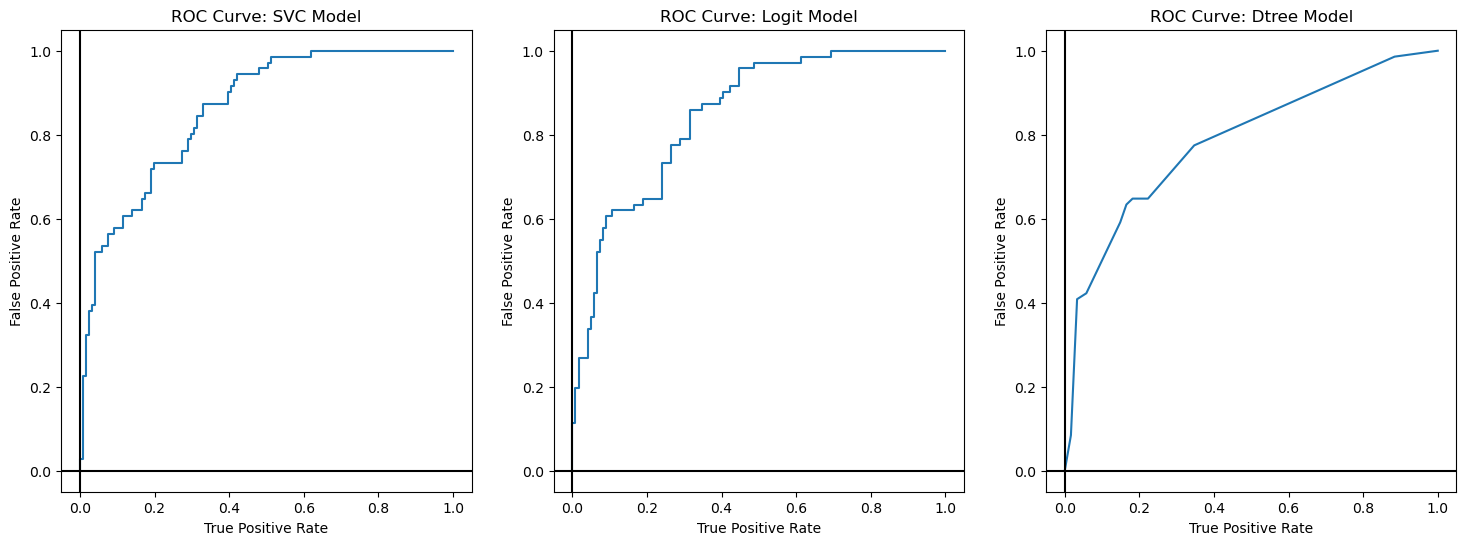

In [38]:
#plot ROC Curves

fig,ax = plt.subplots(1,3,figsize=(18,6))

ax[0].set_title("ROC Curve: SVC Model")
ax[0].set_xlabel("True Positive Rate")
ax[0].set_ylabel("False Positive Rate")
ax[0].plot(svc_fpr, svc_tpr)
ax[0].axhline(y=0, color='k')
ax[0].axvline(x=0, color='k')

ax[1].set_title("ROC Curve: Logit Model")
ax[1].set_xlabel("True Positive Rate")
ax[1].set_ylabel("False Positive Rate")
ax[1].plot(logit_fpr, logit_tpr)
ax[1].axhline(y=0, color='k')
ax[1].axvline(x=0, color='k')

ax[2].set_title("ROC Curve: Dtree Model")
ax[2].set_xlabel("True Positive Rate")
ax[2].set_ylabel("False Positive Rate")
ax[2].plot(dtree_fpr, dtree_tpr)
ax[2].axhline(y=0, color='k')
ax[2].axvline(x=0, color='k')

In [39]:
#We can also get the area under the curve for these values, known as the AUC metric
svc_auc = metrics.auc(svc_fpr,svc_tpr)
logit_auc = metrics.auc(logit_fpr,logit_tpr)
dtree_auc = metrics.auc(dtree_fpr,dtree_tpr)
print(svc_auc,logit_auc,dtree_auc)

0.8586893260388779 0.8467000349202654 0.7846001629612384


# Multi-Class Clasification Models

In [40]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()
df_iris_features = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
df_iris_target = pd.DataFrame(data=iris_dataset.target, columns=['class'])
df_iris_features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [41]:
#Split the dataset
iris_split = train_test_split(
    df_iris_features,
    df_iris_target,
    test_size = 0.25,
    random_state = 17
)
df_iris_features_train = iris_split[0]
df_iris_features_test = iris_split[1]
df_iris_target_train = iris_split[2]
df_iris_target_test = iris_split[3]

In [42]:
#Now lets stratify the dataset
iris_split_strat = train_test_split(
    df_iris_features,
    df_iris_target,
    test_size = 0.25,
    random_state = 17,
    stratify = df_iris_target
)
df_iris_features_train2 = iris_split_strat[0]
df_iris_features_test2 = iris_split_strat[1]
df_iris_target_train2 = iris_split_strat[2]
df_iris_target_test2 = iris_split_strat[3]

In [58]:
mc_dtree_model = DecisionTreeClassifier(max_depth=4)
mc_dtree_model.fit(df_iris_features_train,df_iris_target_train.values.ravel())

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [63]:
mc_predictions = mc_dtree_model.predict(df_iris_features_test)

In [64]:
#Compute confusion matrix
cm_mc_dtree = confusion_matrix(df_iris_target_test.values.ravel(),mc_predictions)

In [61]:
print(cm_mc_dtree)

[[10  0  0]
 [ 0 15  0]
 [ 0  1 12]]


[[10  0  0]
 [ 0 15  0]
 [ 0  1 12]]


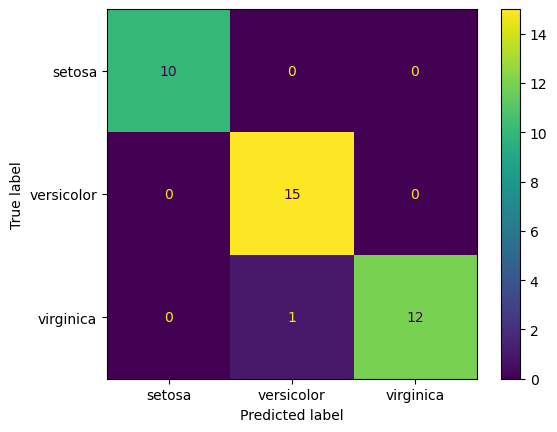

In [67]:
softmax_logit_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=1000)
)

softmax_logit_model.fit(
    df_iris_features_train,
    df_iris_target_train.values.ravel()
)

softmax_logit_predictions = softmax_logit_model.predict(df_iris_features_test)

cm_softmax = confusion_matrix(
    df_iris_target_test.values.ravel(),
    softmax_logit_predictions
)

print(cm_softmax)

ConfusionMatrixDisplay(
    confusion_matrix=cm_softmax,
    display_labels=['setosa', 'versicolor', 'virginica']
).plot()

plt.show()

In [68]:
softmax_logit_model.named_steps['logisticregression'].classes_

array([0, 1, 2])

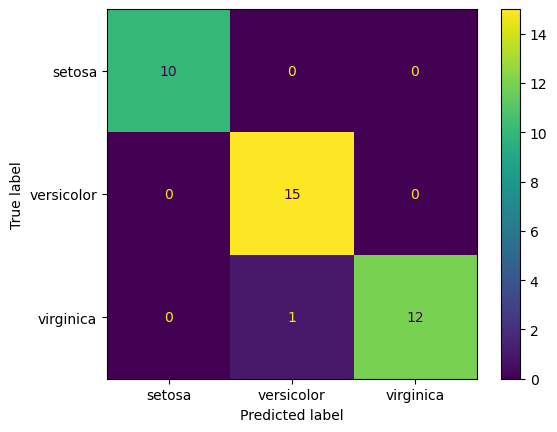

In [69]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_mc_dtree,
    display_labels=['setosa', 'versicolor', 'virginica']
).plot()

# Choosing Hyperparmeter Values

In [76]:
grid_params = {
    'criterion': ['gini','entropy'],
    'splitter': ['best','random'],
    'max_depth': [2,3,4,5,6,7,8,9,10,11,12],
    'min_samples_split': [2,3,4,5,6,7,8,9,10,11,12],
    'max_features':['sqrt','log2']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
                           param_grid = grid_params,
                           scoring='accuracy',
                           cv=10,
                           n_jobs=-1
)

grid_search.fit(df_iris_features.values, df_iris_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [77]:
best_parameters = grid_search.best_params_
print(best_parameters)

{'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 8, 'splitter': 'best'}


In [78]:
best_accuracy = grid_search.best_score_
print(best_accuracy)

0.9733333333333334
